# Section 1
**ABC ANALYSIS LOGIC**

ABC analysis is based on the Pareto principle. In most companies, roughly 20% of products generate 80% of revenue. We classify products into three groups based on their cumulative revenue contribution.

Class A: Top products contributing to the first 70% of total revenue. These are our most valuable items. Typically 10-20% of our product catalog.

Class B: Products contributing to the next 20% of revenue (cumulative 70-90%). Medium value items. Typically 30% of catalog.

Class C: Products contributing to the remaining 10% of revenue (cumulative 90-100%). Low value individually but large in number. Typically 50-60% of catalog.

**XYZ ANALYSIS LOGIC**
XYZ analysis classifies products by how predictable their demand is. The metric we use is the Coefficient of Variation (CV), which is the standard deviation of demand divided by the mean demand. A higher CV means more variable and less predictable demand.

Class X: CV less than 0.5. Demand is stable and predictable. Easy to forecast. Low safety stock needed.

Class Y: CV between 0.5 and 1.0. Demand has some variability, perhaps seasonal or trend-driven. Moderate forecasting difficulty.

Class Z: CV greater than 1.0. Demand is highly irregular and unpredictable. Very hard to forecast. High safety stock needed or make-to-order approach.

**COMBINED ABC-XYZ MATRIX AND WHAT IT MEANS**

AX: High value, predictable. Our most important products. We need to manage very tightly. Continuous review, low safety stock because demand is stable.

AY: High value, somewhat variable. Important but harder to plan. Sophisticated forecasting is needed.

AZ: High value, highly unpredictable. Critical and dangerous. Needs high safety stock or alternative sourcing.

BX: Medium value, predictable. Standard management, periodic review.

BY: Medium value, variable. Moderate attention needed.

BZ: Medium value, unpredictable. We consider whether to keep in catalog.

CX: Low value, predictable. Automate replenishment, minimal attention.

CY: Low value, variable. Low priority management.

CZ: Low value, unpredictable. Candidate for discontinuation or consignment stocking.

# Introduction

**Project Objective**

To simulate the operations of a retail supply chain and analyze inventory using ABC-XYZ classification in order to improve inventory management, reduce stockout risk, and optimize working capital.

**Tools Used**

Python (Pandas, NumPy, Matplotlib, Seaborn)
Excel
Power BI

**Business Problem**

Retail companies often struggle with balancing inventory availability and inventory cost. Some products generate high revenue but have stable demand, while others have unpredictable demand patterns. Without proper classification, companies either overstock or face stockouts.

**This project aims to classify products based on:**

Contribution to revenue (ABC Analysis)
Demand variability (XYZ Analysis)

The project then recommends different inventory policies for each category.

# STEP 1 — Define the Business Scenario

**Description**

A fictional retail company sells multiple consumer products across different categories.

**The company wants to identify:**

Which products are most valuable

Which products have unstable demand

Which products require strict inventory control

**The company also wants recommendations for:**

Safety stock levels

Reorder priority

Inventory monitoring frequency

# STEP 2 — Create Imaginary Dataset

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data={
'Product_ID':['P101','P102','P103','P104','P105','P106','P107','P108','P109','P110'],
'Product_Name':['Wireless Mouse','USB Keyboard','Office Chair','Water Bottle','LED Monitor','Notebook Pack','Backpack','Printer Ink','Coffee Mug','Study Table'],
'Category':['Electronics','Electronics','Furniture','Household','Electronics','Stationery','Accessories','Electronics','Household','Furniture'],
'Annual_Demand':[12000,9500,1400,22000,2800,18000,4200,3500,8000,900],
'Unit_Price':[15,20,120,5,180,3,40,35,8,220],
'Monthly_Demand_StdDev':[120,90,250,60,450,40,310,520,70,410],
'Lead_Time_Days':[7,5,20,4,18,3,12,10,6,25]
}

df=pd.DataFrame(data)

df.head()


,Product_ID,Product_Name,Category,Annual_Demand,Unit_Price,Monthly_Demand_StdDev,Lead_Time_Days
0,P101,Wireless Mouse,Electronics,12000,15,120,7
1,P102,USB Keyboard,Electronics,9500,20,90,5
2,P103,Office Chair,Furniture,1400,120,250,20
3,P104,Water Bottle,Household,22000,5,60,4
4,P105,LED Monitor,Electronics,2800,180,450,18


# STEP 3 — Calculate Annual Consumption Value

Raw data alone is not useful. Supply chain decisions require aggregated financial and demand metrics.

**We create two key business indicators**:

1. Monthly Average Demand

Helps understand regular consumption pattern.

2. Annual Consumption Value

This is extremely important — it represents money tied to inventory demand.

**Formula:**

Annual Consumption Value = Annual Demand × Unit Price

**This metric tells:** Which products bring the most revenue/value to the company?

In [3]:
df["Monthly_Demand_Avg"] = df["Annual_Demand"] / 12
df["Annual_Consumption_Value"] = df["Annual_Demand"] * df["Unit_Price"]

df.head()

,Product_ID,Product_Name,Category,Annual_Demand,Unit_Price,Monthly_Demand_StdDev,Lead_Time_Days,Monthly_Demand_Avg,Annual_Consumption_Value
0,P101,Wireless Mouse,Electronics,12000,15,120,7,1000.000000,180000
1,P102,USB Keyboard,Electronics,9500,20,90,5,791.666667,190000
2,P103,Office Chair,Furniture,1400,120,250,20,116.666667,168000
3,P104,Water Bottle,Household,22000,5,60,4,1833.333333,110000
4,P105,LED Monitor,Electronics,2800,180,450,18,233.333333,504000


# STEP 4 — ABC Analysis (Value-Based Segmentation)

**ABC analysis is based on the Pareto principle (80/20 rule):**

Small number of products contribute most of the value

Large number of products contribute little value

**We classify products into:**

A-Class → High value (most important)

B-Class → Medium value

C-Class → Low value

**Business Meaning:**

A items = tight control, frequent monitoring

C items = low priority, bulk ordering

**Steps:**

Sort products by value

Compute cumulative contribution

Convert into percentage

Assign class

In [4]:
df = df.sort_values(by="Annual_Consumption_Value", ascending=False)

df["Cumulative_Value"] = df["Annual_Consumption_Value"].cumsum()

total_value = df["Annual_Consumption_Value"].sum()

df["Cumulative_Percentage"] = (df["Cumulative_Value"] / total_value) * 100

def abc_class(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"

df["ABC_Class"] = df["Cumulative_Percentage"].apply(abc_class)

df[["Product_Name","Annual_Consumption_Value","Cumulative_Percentage","ABC_Class"]]

,Product_Name,Annual_Consumption_Value,Cumulative_Percentage,ABC_Class
4,LED Monitor,504000,28.660790,A
9,Study Table,198000,39.920387,A
1,USB Keyboard,190000,50.725050,A
0,Wireless Mouse,180000,60.961046,A
6,Backpack,168000,70.514643,A
2,Office Chair,168000,80.068240,B
7,Printer Ink,122500,87.034404,B
3,Water Bottle,110000,93.289736,B
8,Coffee Mug,64000,96.929201,C
5,Notebook Pack,54000,100.000000,C


# STEP 5 — XYZ Analysis (Demand Variability Classification)

ABC tells us value importance, but not stability.

XYZ analysis tells us: “How predictable is demand?”

We use Coefficient of Variation (CV):

**Formula:**
CV = Standard Deviation / Mean Demand

**Business Meaning:**

X = stable demand → easy forecasting

Y = moderate fluctuation

Z = highly unpredictable → risky inventory

**Why it matters:**

Unstable demand = risk of:

stockouts

overstocking

poor forecasting accuracy

In [5]:
df["CV"] = df["Monthly_Demand_StdDev"] / df["Monthly_Demand_Avg"]

def xyz_class(cv):
    if cv <= 0.5:
        return "X"
    elif cv <= 1.0:
        return "Y"
    else:
        return "Z"

df["XYZ_Class"] = df["CV"].apply(xyz_class)

df[["Product_Name","Monthly_Demand_Avg","Monthly_Demand_StdDev","CV","XYZ_Class"]]

,Product_Name,Monthly_Demand_Avg,Monthly_Demand_StdDev,CV,XYZ_Class
4,LED Monitor,233.333333,450,1.928571,Z
9,Study Table,75.000000,410,5.466667,Z
1,USB Keyboard,791.666667,90,0.113684,X
0,Wireless Mouse,1000.000000,120,0.120000,X
6,Backpack,350.000000,310,0.885714,Y
2,Office Chair,116.666667,250,2.142857,Z
7,Printer Ink,291.666667,520,1.782857,Z
3,Water Bottle,1833.333333,60,0.032727,X
8,Coffee Mug,666.666667,70,0.105000,X
5,Notebook Pack,1500.000000,40,0.026667,X


# STEP 6 — Combine ABC and XYZ (Strategic Segmentation)

Now we combine both analyses:

ABC = financial importance

XYZ = demand stability

This creates a decision-making matrix used in real companies

**Example:**

AX → valuable + stable → best products

AZ → valuable + unstable → high risk items

CZ → low value + unstable → worst category

**This step turns data into strategy.**

In [6]:
df["ABC_XYZ"] = df["ABC_Class"] + df["XYZ_Class"]

df[["Product_Name","ABC_Class","XYZ_Class","ABC_XYZ"]]

,Product_Name,ABC_Class,XYZ_Class,ABC_XYZ
4,LED Monitor,A,Z,AZ
9,Study Table,A,Z,AZ
1,USB Keyboard,A,X,AX
0,Wireless Mouse,A,X,AX
6,Backpack,A,Y,AY
2,Office Chair,B,Z,BZ
7,Printer Ink,B,Z,BZ
3,Water Bottle,B,X,BX
8,Coffee Mug,C,X,CX
5,Notebook Pack,C,X,CX


# STEP 7 — Inventory Strategy Design

We translate analytics into actionable inventory policies.

**We assign strategies:**

AX → lean inventory, tight control

AZ → high safety stock, forecasting focus

CX → minimal attention

In [7]:
def strategy(cat):
    if cat == "AX":
        return "High value & stable → tight control, lean inventory"
    elif cat == "AY":
        return "Moderate monitoring with periodic review"
    elif cat == "AZ":
        return "Critical item → high safety stock + forecasting focus"
    elif cat == "BX":
        return "Stable medium value → automated replenishment"
    elif cat == "BY":
        return "Standard review cycle"
    elif cat == "BZ":
        return "Monitor closely due to unpredictability"
    elif cat == "CX":
        return "Low priority → bulk ordering"
    elif cat == "CY":
        return "Occasional review"
    else:
        return "Minimize inventory holding cost"

df["Inventory_Strategy"] = df["ABC_XYZ"].apply(strategy)

df[["Product_Name","ABC_XYZ","Inventory_Strategy"]]

,Product_Name,ABC_XYZ,Inventory_Strategy
4,LED Monitor,AZ,Critical item → high safety stock + forecastin...
9,Study Table,AZ,Critical item → high safety stock + forecastin...
1,USB Keyboard,AX,"High value & stable → tight control, lean inve..."
0,Wireless Mouse,AX,"High value & stable → tight control, lean inve..."
6,Backpack,AY,Moderate monitoring with periodic review
2,Office Chair,BZ,Monitor closely due to unpredictability
7,Printer Ink,BZ,Monitor closely due to unpredictability
3,Water Bottle,BX,Stable medium value → automated replenishment
8,Coffee Mug,CX,Low priority → bulk ordering
5,Notebook Pack,CX,Low priority → bulk ordering


# STEP 8 — Visualization (Business Interpretation)

Visualization converts numbers into decision intelligence.

Managers do not read tables — they read visuals.

We create:

Bar chart → value distribution

Helps identify A items quickly

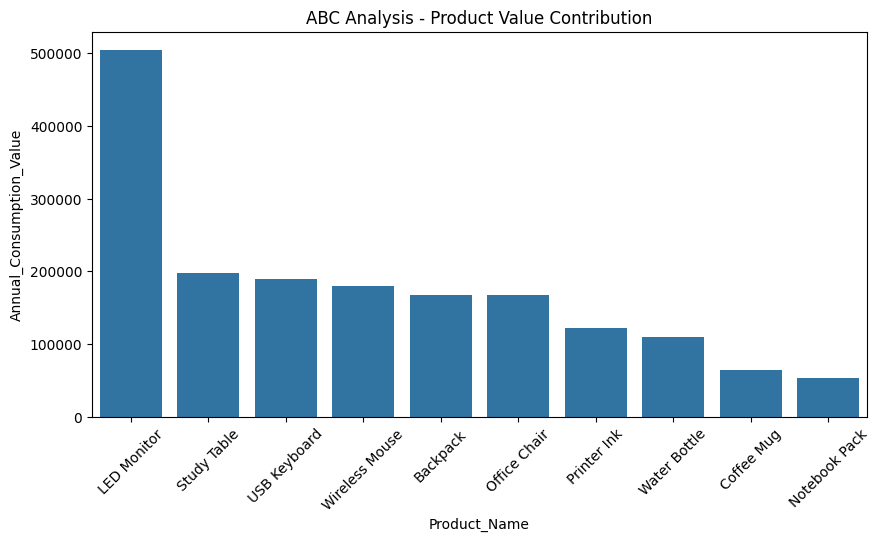

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x="Product_Name", y="Annual_Consumption_Value", data=df)
plt.xticks(rotation=45)
plt.title("ABC Analysis - Product Value Contribution")
plt.show()

# STEP 9 — ABC-XYZ Heatmap (Strategic View)

Heatmap shows product distribution across strategy matrix.

This is a classic supply chain decision tool.

**It helps answer:** Where are most risky products located?

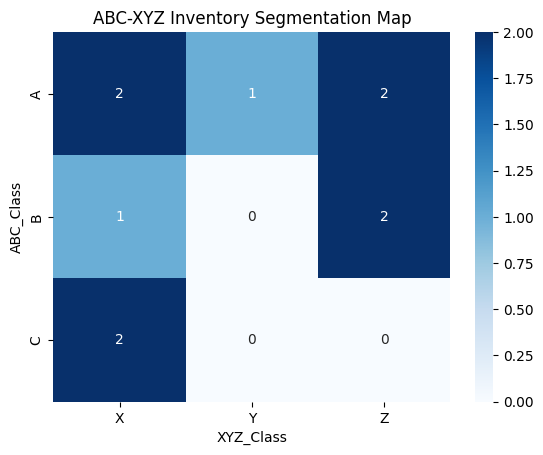

In [9]:
pivot = pd.crosstab(df["ABC_Class"], df["XYZ_Class"])

sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("ABC-XYZ Inventory Segmentation Map")
plt.show()

### Product Distribution by ABC Class

Let's visualize the number of products in each ABC class to understand the proportion of high, medium, and low-value items.

/tmp/ipykernel_4646/4292552811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ABC_Class', data=df, order=['A', 'B', 'C'], palette='viridis')


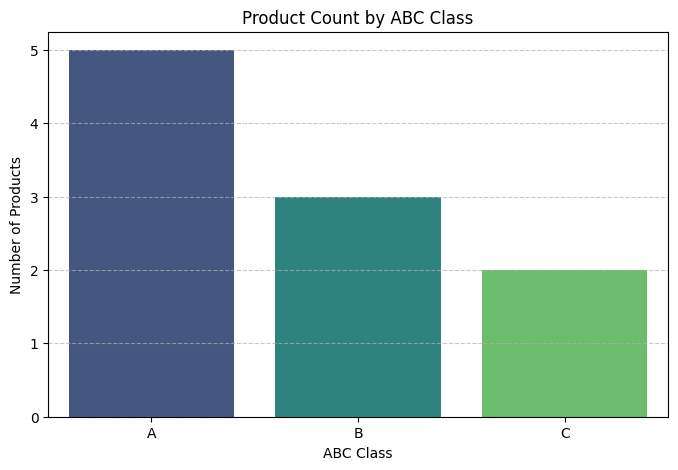

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='ABC_Class', data=df, order=['A', 'B', 'C'], palette='viridis')
plt.title('Product Count by ABC Class')
plt.xlabel('ABC Class')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Product Distribution by XYZ Class

Similarly, let's visualize the number of products in each XYZ class to understand the proportion of stable, variable, and unpredictable demand items.


/tmp/ipykernel_4646/2496936063.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='XYZ_Class', data=df, order=['X', 'Y', 'Z'], palette='plasma')


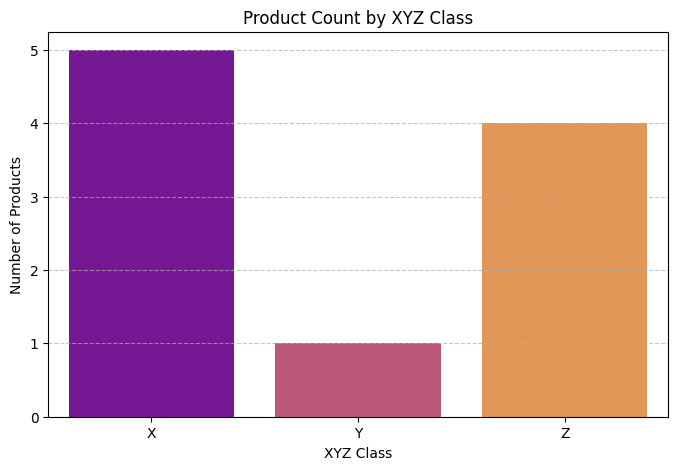

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='XYZ_Class', data=df, order=['X', 'Y', 'Z'], palette='plasma')
plt.title('Product Count by XYZ Class')
plt.xlabel('XYZ Class')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# STEP 10 — Business Insights (Decision Layer)

This step converts analysis into executive-level insights.

In this step, we convert analytical results into business conclusions. These insights help managers understand inventory behavior and take decisions regarding stocking strategy, forecasting, and cost control.

**Key Insights**

**A-class** products contribute the majority of total inventory value, so they require strict monitoring and control.

**Z-class** products show highly unpredictable demand, making them risky for inventory planning and requiring advanced forecasting techniques.

**AX products** are both high value and stable, making them ideal for lean inventory management.

**AZ products** are high value but unstable, which increases financial risk and requires higher safety stock.

**CX products** have low value and unstable demand, so maintaining large inventory for them is not cost-efficient.

# STEP 11 — Export Final Dataset

In real companies, output is shared with:

Supply chain managers

Finance teams

BI dashboards

**We export the dataset for Power BI or Excel reporting.**

In [11]:
df.to_csv("ABC_XYZ_Supply_Chain_Final.csv", index=False)

In [12]:
from google.colab import files

files.download("ABC_XYZ_Supply_Chain_Final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>